# 실습 주제
- 식당 팁(Tip) 예측 모형 생성을 통한 기초 통계 및 데이터 분석 종합 실습

## 실습 목표
- 학습한 전처리 기법과 회귀 분석을 활용하여 Test 데이터 기준 예측 오차(MAPE, Mean Absolute Percentage Error)를 최소화하는 최적의 모형을 구축

## 데이터셋
- seaborn에서 제공하는 tips 데이터셋 (아래에 제공한 코드 이용)

---
## 실습 조건
- 분석 데이터 로드: 아래 코드를 복사해 데이터를 가져오세요.
- Target 변수: tip (지불한 팁 금액, 달러) 
- 파생 변수 생성: 주어진 변수를 조합해, 팁 금액에 영향을 미칠 만한 논리적인 파생변수를 최소 2개 이상 생성합니다. (예: 1인당 식사 금액, 주말 여부 등)
- Data Partition: train_test_split 함수를 사용해 분석용 데이터와 평가용 데이터를 8:2로 분할합니다. 
- 데이터 전처리: 수업 시간에 배운 기법을 활용해 다음 과정을 반드시 포함합니다. 
- 결측치 또는 이상치 탐지 및 처리 (합리적인 기준 적용)
- 연속형 변수에 대한 분포 확인 및 스케일링 (Min-Max 또는 Standard)
- 범주형 변수에 대한 One-hot Encoding
- 회귀 분석 모델: statsmodels.api 라이브러리를 사용합니다.



In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


# 라이브러리

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 데이터 분석
- 분석 데이터 로드: 아래 코드를 복사해 데이터를 가져오세요.


In [21]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.shape

(244, 7)

In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


- 결측치 존재하지 않음

In [17]:
for col in df.columns:
    print(f"컬럼: {col:15s} | 타입: {str(df[col].dtype):10s} | 고유값 개수: {df[col].nunique()}")

컬럼: total_bill      | 타입: float64    | 고유값 개수: 229
컬럼: tip             | 타입: float64    | 고유값 개수: 123
컬럼: sex             | 타입: category   | 고유값 개수: 2
컬럼: smoker          | 타입: category   | 고유값 개수: 2
컬럼: day             | 타입: category   | 고유값 개수: 4
컬럼: time            | 타입: category   | 고유값 개수: 2
컬럼: size            | 타입: int64      | 고유값 개수: 6


- 변수 종류 7개 / 범주형, 연속형 나눠져있음 

### 변수 선택
- Target 변수: tip (지불한 팁 금액, 달러) 
- 파생 변수 생성: 주어진 변수를 조합해, 팁 금액에 영향을 미칠 만한 논리적인 파생변수를 최소 2개 이상 생성합니다. (예: 1인당 식사 금액, 주말 여부 등)

연속형 변수: ['total_bill', 'tip', 'size']


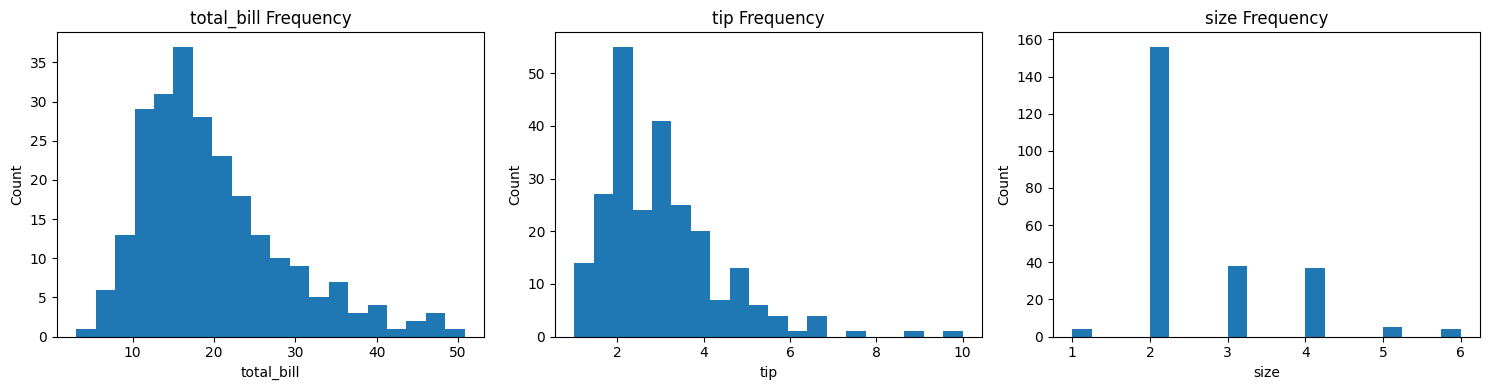

In [22]:
# 연속형 변수 자동 추출
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("연속형 변수:", num_cols)

# 빈도 분포 히스토그램

n = len(num_cols)
cols = 3     # 한 행에 그래프 갯수
rows = (n // cols) + (n % cols > 0)

plt.figure(figsize=(cols*5, rows*4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"{col} Frequency")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()